Mounted at /content/drive
Drive zip dir: /content/drive/MyDrive/Computer Vision Weed Detection/Data_zip
Contents of Data_zip on Drive: ['Tomato_1', 'Tomato_2', 'Maize_1', 'Maize_2']
Unzipping Data_zip to local SSD...
Found 24 zip files to extract.


Extracting zip files:   0%|          | 0/24 [00:00<?, ?it/s]

Local data dir: /content/data/Data
Scene dirs locally: ['Maize_1', 'Maize_2', 'Tomato_1', 'Tomato_2']
Using base_dir: /content/data/Data
Cleaning unwanted system folders...
Cleanup complete. Removed 3 unwanted folders/files.
Top-level scene folders: ['Maize_1', 'Maize_2', 'Tomato_1', 'Tomato_2']

Subfolders under each scene:
Maize_1 -> ['maize_1_convolvulus', 'maize_1_sorghum', 'maize_1_atriplex', 'maize_1_datura', 'maize_1_lolium', 'maize_1_chenopodium', 'maize_1', 'maize_1_salsola']
Maize_2 -> ['maize_2_convolvulus', 'maize_2_datura', 'maize_2_chenopodium', 'maize_2', 'maize_2_atriplex', 'maize_2_lolium', 'maize_2_salsola', 'maize_2_sorghum']
Tomato_1 -> ['tomato_1_cyperus', 'tomato_1_portulaca', 'tomato_1', 'tomato_1_solanum']
Tomato_2 -> ['tomato_2', 'tomato_2_portulaca', 'tomato_2_cyperus', 'tomato_2_solanum']

Number of classes: 24
Classes: ['maize_1', 'maize_1_atriplex', 'maize_1_chenopodium', 'maize_1_convolvulus', 'maize_1_datura', 'maize_1_lolium', 'maize_1_salsola', 'maize_1

100%|██████████| 97.8M/97.8M [00:00<00:00, 219MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

...

  0%|          | 0/421 [00:00<?, ?it/s]

Train loss: 0.3886 | Train acc: 0.8936 | Test loss: 0.3775 | Test acc: 0.9008

Epoch 3/3


  0%|          | 0/1684 [00:00<?, ?it/s]

  0%|          | 0/421 [00:00<?, ?it/s]

Train loss: 0.3376 | Train acc: 0.9021 | Test loss: 0.3795 | Test acc: 0.9158

Time for 3 epoch(s): 1712.03 seconds


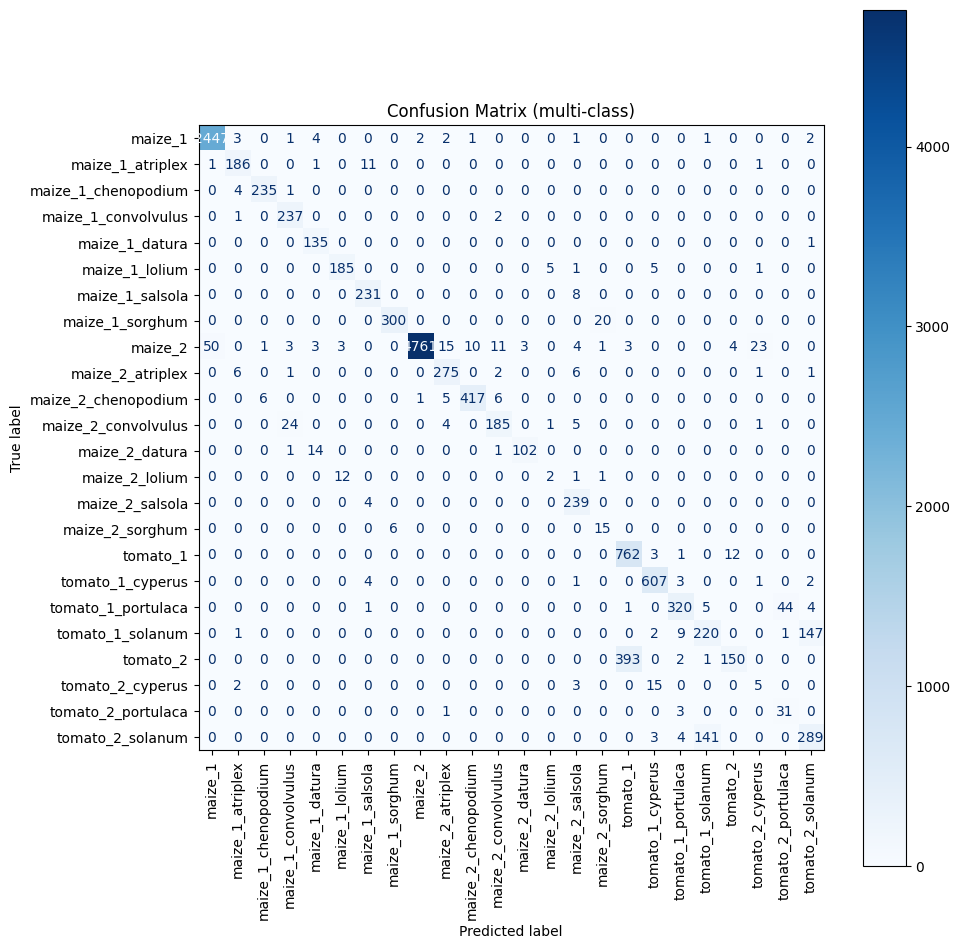

Confusion matrix shape: (24, 24)

Model saved successfully to:
/content/drive/MyDrive/Computer Vision Weed Detection/models/resnet50_multiclass_folderlabel.pth
Model and optimizer successfully loaded.
Loaded classes: {'maize_1': 0, 'maize_1_atriplex': 1, 'maize_1_chenopodium': 2, 'maize_1_convolvulus': 3, 'maize_1_datura': 4, 'maize_1_lolium': 5, 'maize_1_salsola': 6, 'maize_1_sorghum': 7, 'maize_2': 8, 'maize_2_atriplex': 9, 'maize_2_chenopodium': 10, 'maize_2_convolvulus': 11, 'maize_2_datura': 12, 'maize_2_lolium': 13, 'maize_2_salsola': 14, 'maize_2_sorghum': 15, 'tomato_1': 16, 'tomato_1_cyperus': 17, 'tomato_1_portulaca': 18, 'tomato_1_solanum': 19, 'tomato_2': 20, 'tomato_2_cyperus': 21, 'tomato_2_portulaca': 22, 'tomato_2_solanum': 23}


In [ ]:
# ===============================
# 1. Mount Google Drive & unzip Data_zip to local SSD
# ===============================
from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile
from tqdm.auto import tqdm

# Project root where your notebook and Data_zip live
project_root = "/content/drive/MyDrive/Computer Vision Weed Detection"

# Folder on Drive that contains the zipped data
drive_zip_dir = os.path.join(project_root, "Data_zip")
print("Drive zip dir:", drive_zip_dir)
print("Contents of Data_zip on Drive:", os.listdir(drive_zip_dir))

# Local target folder on fast Colab SSD (unzipped images)
local_root = "/content/data"
local_data_dir = os.path.join(local_root, "Data")

os.makedirs(local_root, exist_ok=True)

def unzip_with_progress(zip_root, target_root):
    """
    Walks through zip_root, finds all .zip files and extracts them
    to target_root, keeping the relative folder structure.
    """
    zip_paths = []
    for root, _, files in os.walk(zip_root):
        for f in files:
            if f.lower().endswith(".zip"):
                zip_paths.append(os.path.join(root, f))

    print(f"Found {len(zip_paths)} zip files to extract.")

    for zip_path in tqdm(zip_paths, desc="Extracting zip files"):
        # Keep relative folder structure
        rel_folder = os.path.relpath(os.path.dirname(zip_path), zip_root)
        extract_dir = os.path.join(target_root, rel_folder)
        os.makedirs(extract_dir, exist_ok=True)

        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)

# Only unzip if not already unzipped
if not os.path.exists(local_data_dir):
    print("Unzipping Data_zip to local SSD...")
    unzip_with_progress(drive_zip_dir, local_data_dir)
else:
    print("Local Data folder already exists, skipping unzip.")

print("Local data dir:", local_data_dir)
print("Scene dirs locally:", os.listdir(local_data_dir))

# ===============================
# 2. Clean unwanted folders & build items list (MULTI-CLASS)
# ===============================
import shutil

base_dir = local_data_dir  # "/content/data/Data"
print("Using base_dir:", base_dir)

# Remove unwanted system folders (__MACOSX, .DS_Store, .ipynb_checkpoints)
def clean_unwanted_folders(base_dir):
    unwanted = ["__MACOSX", ".DS_Store", ".ipynb_checkpoints"]
    removed = 0

    for root, dirs, files in os.walk(base_dir):
        for d in list(dirs):
            if d in unwanted or d.startswith("__"):
                shutil.rmtree(os.path.join(root, d), ignore_errors=True)
                removed += 1
        for f in list(files):
            if f in unwanted:
                file_path = os.path.join(root, f)
                os.remove(file_path)
                removed += 1

    print(f"Cleanup complete. Removed {removed} unwanted folders/files.")

print("Cleaning unwanted system folders...")
clean_unwanted_folders(base_dir)

# Top-level scene folders (e.g. Maize_2, Maize_1, Tomato_2, Tomato_1)
scene_dirs = [
    d for d in os.listdir(base_dir)
    if os.path.isdir(os.path.join(base_dir, d))
]
print("Top-level scene folders:", scene_dirs)

from collections import defaultdict

subdirs_by_scene = defaultdict(list)

for scene in scene_dirs:
    scene_path = os.path.join(base_dir, scene)
    for name in os.listdir(scene_path):
        path = os.path.join(scene_path, name)
        if os.path.isdir(path) and not name.startswith("__"):
            subdirs_by_scene[scene].append(name)

print("\nSubfolders under each scene:")
for scene, subdirs in subdirs_by_scene.items():
    print(scene, "->", subdirs)

def is_image_file(path: str) -> bool:
    ext = os.path.splitext(path)[1].lower()
    return ext in [".jpg", ".jpeg", ".png", ".bmp"]

# ---- NEW: build global class_name -> index mapping ----
# We keep every folder name as its own class label.
all_class_names = sorted(list({
    class_name
    for scene in scene_dirs
    for class_name in os.listdir(os.path.join(base_dir, scene))
    if os.path.isdir(os.path.join(base_dir, scene, class_name))
    and not class_name.startswith("__")
}))

class_to_idx = {name: idx for idx, name in enumerate(all_class_names)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}

print("\nNumber of classes:", len(all_class_names))
print("Classes:", all_class_names)

# Build items list: (image_path, label_idx, class_name, scene)
items = []

for scene in scene_dirs:
    scene_path = os.path.join(base_dir, scene)

    for class_name in os.listdir(scene_path):
        class_path = os.path.join(scene_path, class_name)

        if not os.path.isdir(class_path):
            continue  # Skip files
        if class_name.startswith("__"):
            continue  # Skip system folders (just in case)

        # Multi-class label: one class index per folder name
        if class_name not in class_to_idx:
            raise ValueError(f"Folder '{class_name}' not found in class_to_idx mapping")

        label_idx = class_to_idx[class_name]

        # Collect all image paths recursively
        for root, _, files in os.walk(class_path):
            for fname in files:
                full_path = os.path.join(root, fname)
                if is_image_file(full_path):
                    items.append((full_path, label_idx, class_name, scene))

print(f"\nTotal images found: {len(items)}")
print("Example item:", items[0] if items else "No images found")

# ===============================
# 3. Dataset + DataLoader (ResNet-50 transforms) - MULTI-CLASS
# ===============================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image, UnidentifiedImageError
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# Speed optimizations
torch.backends.cudnn.benchmark = True

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Pretrained ResNet-50 weights and transforms
weights = ResNet50_Weights.IMAGENET1K_V1
preprocess = weights.transforms()  # Resize + CenterCrop + ToTensor + Normalize

class CropWeedMultiDataset(Dataset):
    """
    Dataset for multi-class classification.
    Uses `items` = (img_path, label_idx, fine_class_name, scene_name)
    and returns (image_tensor, label_tensor).
    """
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, label_idx, fine_class, scene = self.items[idx]

        # Robust image loading
        try:
            img = Image.open(img_path).convert("RGB")
        except (UnidentifiedImageError, OSError) as e:
            print(f"[WARN] Could not read image: {img_path} ({e}). Using black dummy image instead.")
            img = Image.new("RGB", (256, 256), (0, 0, 0))

        if self.transform is not None:
            img = self.transform(img)

        label = torch.tensor(label_idx, dtype=torch.long)
        return img, label

# Stratified train/test split based on multi-class labels
labels_for_stratify = [label for (_, label, _, _) in items]

train_items, test_items = train_test_split(
    items,
    test_size=0.2,
    random_state=42,
    stratify=labels_for_stratify
)

from collections import Counter
print("Train label distribution:", Counter([lbl for _, lbl, _, _ in train_items]))
print("Test label distribution:",  Counter([lbl for _, lbl, _, _ in test_items]))

train_dataset = CropWeedMultiDataset(train_items, transform=preprocess)
test_dataset  = CropWeedMultiDataset(test_items,  transform=preprocess)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

# Sanity check
images, labels = next(iter(train_loader))
print("Batch shapes:", images.shape, labels.shape)

# ===============================
# 4. Pretrained ResNet-50 head for N classes
# ===============================
num_classes = len(all_class_names)

# Load pretrained ResNet-50
model = resnet50(weights=weights)

# Replace final fully connected layer to output num_classes
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)
print(model)

# ===============================
# 5. Loss (with class weights for multi-class) + Optimizer
# ===============================
from collections import Counter

train_labels = [lbl for _, lbl, _, _ in train_items]
label_counts_train = Counter(train_labels)
print("Train label counts:", label_counts_train)

total = sum(label_counts_train.values())
# Compute inverse-frequency weights for all classes
class_weights_list = []
for idx in range(num_classes):
    count = label_counts_train.get(idx, 1)  # avoid division by zero
    class_weights_list.append(total / count)

class_weights = torch.tensor(class_weights_list, dtype=torch.float32).to(device)
print("Class weights (per class index):", class_weights)

loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  # smaller LR for finetuning

# ===============================
# 6. Train / Test loops
# ===============================
def train_step(model, dataloader, loss_fn, optimizer, device):
    model.train()
    train_loss, train_acc = 0.0, 0.0

    for images, labels in tqdm(dataloader, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = loss_fn(logits, labels)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)
        batch_acc = (preds == labels).sum().item() / len(labels)
        train_acc += batch_acc

    train_loss /= len(dataloader)
    train_acc  /= len(dataloader)
    return train_loss, train_acc


def test_step(model, dataloader, loss_fn, device):
    model.eval()
    test_loss, test_acc = 0.0, 0.0

    with torch.inference_mode():
        for images, labels in tqdm(dataloader, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = loss_fn(logits, labels)
            test_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            batch_acc = (preds == labels).sum().item() / len(labels)
            test_acc += batch_acc

    test_loss /= len(dataloader)
    test_acc  /= len(dataloader)
    return test_loss, test_acc


def train(model, train_loader, test_loader, optimizer, loss_fn, epochs, device):
    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        train_loss, train_acc = train_step(model, train_loader, loss_fn, optimizer, device)
        test_loss, test_acc   = test_step(model, test_loader, loss_fn, device)

        print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | "
              f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results

# ===============================
# 7. Training run
# ===============================
from timeit import default_timer as timer

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

EPOCHS = 3  # adjust as needed

start = timer()
results = train(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=EPOCHS,
    device=device
)
end = timer()
print(f"\nTime for {EPOCHS} epoch(s): {end - start:.2f} seconds")

# ===============================
# 8. Confusion Matrix on Test Set (multi-class)
# ===============================
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def plot_confusion_matrix(model, dataloader, device, class_names):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.inference_mode():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    # If many classes, you may want to increase figure size
    fig, ax = plt.subplots(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', values_format='d', xticks_rotation=90)
    plt.title("Confusion Matrix (multi-class)")
    plt.tight_layout()
    plt.show()

    return cm

cm = plot_confusion_matrix(model, test_loader, device, all_class_names)
print("Confusion matrix shape:", cm.shape)

# ===============================
# 9. Save trained model (multi-class version)
# ===============================

# Path on Google Drive where the model will be saved
save_dir = "/content/drive/MyDrive/Computer Vision Weed Detection/models"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "resnet50_multiclass_folderlabel.pth")

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": EPOCHS,
    "class_weights": class_weights,
    "results": results,
    "class_to_idx": class_to_idx,
    "idx_to_class": idx_to_class,
}, save_path)

print(f"\nModel saved successfully to:\n{save_path}")

# ===============================
# (Optional) Load model
# ===============================
checkpoint = torch.load(save_path, map_location=device)

loaded_class_to_idx = checkpoint["class_to_idx"]
loaded_idx_to_class = checkpoint["idx_to_class"]
loaded_num_classes = len(loaded_class_to_idx)

model = resnet50(weights=None)  # No pretrained weights here for reload
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, loaded_num_classes)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

print("Model and optimizer successfully loaded.")
print("Loaded classes:", loaded_class_to_idx)